# Лабораторная работа: воссоздание GPT-1 на PyTorch

## Цель работы
В этой лабораторной работе нужно реализовать упрощённую версию модели GPT-1 на языке Python с использованием PyTorch.

## Что будет сделано
1. Подготовка текста и токенизация при помощи BPE.
2. Реализация эмбеддингов и декодерного блока Transformer.
3. Сборка полной модели GPT.
4. Обучение модели на текстовых данных.
5. Генерация текста после обучения.

## Среда выполнения
Работа выполняется в Jupyter Notebook в Visual Studio Code на Ubuntu.
Если доступна видеокарта, вычисления будут выполняться на GPU.

In [29]:
#%pip install dill
#%pip install torch

In [30]:
# Базовые библиотеки
import os
import math
import dill
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

# Для повторяемости результатов
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Выбираем устройство: GPU, если он доступен
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Текущее устройство:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    # иногда это немного ускоряет вычисления
    torch.backends.cudnn.benchmark = True
    
    # на новых версиях pytorch это может ускорить matmul
    try:
        torch.set_float32_matmul_precision("high")
    except:
        pass

Текущее устройство: cuda
GPU: NVIDIA GeForce RTX 3070


In [31]:
class BPE:
    """
    Реализация Byte Pair Encoding.
    Будем строить словарь из символов, а потом постепенно
    объединять самые частые соседние пары.
    """
    
    def __init__(self, vocab_size: int):
        self.vocab_size = vocab_size
        self.id2token = None
        self.token2id = None

    def fit(self, text: str):
        # начальный словарь: все уникальные символы текста
        unique_tokens = sorted(set(text))
        tokens = list(text)

        # расширяем словарь, пока не дойдём до нужного размера
        while len(unique_tokens) < self.vocab_size:
            pair_counts = {}

            # считаем частоты соседних пар
            for i in range(len(tokens) - 1):
                pair = (tokens[i], tokens[i + 1])
                if pair not in pair_counts:
                    pair_counts[pair] = 0
                pair_counts[pair] += 1

            # если пар больше нет, выходим
            if len(pair_counts) == 0:
                break

            # ищем самую частую пару
            best_pair = None
            best_freq = 0
            for pair, freq in pair_counts.items():
                if freq > best_freq:
                    best_freq = freq
                    best_pair = pair

            # создаём новый токен из этой пары
            new_token = best_pair[0] + best_pair[1]
            unique_tokens.append(new_token)

            # объединяем найденную пару в тексте
            new_tokens = []
            i = 0
            while i < len(tokens):
                if i < len(tokens) - 1 and tokens[i] == best_pair[0] and tokens[i + 1] == best_pair[1]:
                    new_tokens.append(new_token)
                    i += 2
                else:
                    new_tokens.append(tokens[i])
                    i += 1

            tokens = new_tokens

        # формируем словари token <-> id
        unique_tokens = unique_tokens[:self.vocab_size]
        self.id2token = {i: token for i, token in enumerate(unique_tokens)}
        self.token2id = {token: i for i, token in self.id2token.items()}

    def encode(self, text: str):
        """
        Преобразует строку в список id.
        Сначала текст разбивается на символы, потом пытаемся
        склеивать пары, если они уже есть в словаре.
        """
        tokens = list(text)

        changed = True
        while changed:
            changed = False
            new_tokens = []
            i = 0

            while i < len(tokens):
                if i < len(tokens) - 1:
                    pair = tokens[i] + tokens[i + 1]

                    if pair in self.token2id:
                        new_tokens.append(pair)
                        i += 2
                        changed = True
                    else:
                        new_tokens.append(tokens[i])
                        i += 1
                else:
                    new_tokens.append(tokens[i])
                    i += 1

            tokens = new_tokens

        ids = []
        for token in tokens:
            if token in self.token2id:
                ids.append(self.token2id[token])
            else:
                # запасной вариант: если токен не нашли,
                # разбиваем его обратно на символы
                for ch in token:
                    ids.append(self.token2id.get(ch, 0))

        return ids

    def decode(self, ids):
        """
        Преобразует список id обратно в строку.
        """
        return "".join(self.id2token[i] for i in ids)

    def save(self, filename):
        with open(filename, "wb") as f:
            dill.dump(self, f)
        print(f"BPE сохранён в файл: {filename}")

    @classmethod
    def load(cls, filename):
        with open(filename, "rb") as f:
            obj = dill.load(f)
        print(f"BPE загружен из файла: {filename}")
        return obj

## Подготовка текстовых данных

Теперь загрузим текст, на котором будет обучаться модель.

Для обучения GPT нужен один большой текст.
Если текстов несколько, их нужно объединить в одну строку.

В папке `texts` должны лежат `.txt` файлы с текстами.

- `texts/book1.txt`
- `texts/book2.txt`

Все файлы будут прочитаны и объединены.

In [51]:
import glob

# Путь к папке с текстами
TEXTS_DIR = "./texts"

# Ищем все txt-файлы
file_paths = sorted(glob.glob(os.path.join(TEXTS_DIR, "*.txt")))

print("Найдено файлов:", len(file_paths))
for path in file_paths[:10]:
    print(path)

# Считываем все тексты в один большой текст
all_texts = []

for file_path in file_paths:
    with open(file_path, "r", encoding="utf-8") as f:
        text_part = f.read().strip()
        if len(text_part) > 0:
            all_texts.append(text_part)

# Объединяем тексты
all_text = "\n\n".join(all_texts)

print("\nОбщая длина текста:", len(all_text))
print("\nПервые 500 символов:\n")
print(all_text[:500])

Найдено файлов: 2
./texts/book1.txt
./texts/book2.txt

Общая длина текста: 656775

Первые 500 символов:

Джек Сумасшедший король
Андрей Олегович Белянин


Джек Сумасшедший король #1
Самый настоящий принц, прозванный Сумасшедшим королем, и его неугомонная и крайне разношерстная компания ведут почти безостановочную борьбу со всякой нечистью. К тому же из любой переделки выходят победителями.





Андрей Белянин

Джек Сумасшедший король





Книга первая


В деревне его называли Сумасшедшим королем. Надо признать, что прозвище ему подходило. К тому же его настоящего имени никто не знал. Он пришел в де


In [33]:
# Размер словаря BPE
# Можно начать с 1000-2000, чтобы ноутбук не работал слишком долго
VOCAB_SIZE = 2000

# Создаём и обучаем BPE
bpe = BPE(vocab_size=VOCAB_SIZE)
bpe.fit(all_text)

print("Размер словаря:", len(bpe.id2token))

# Сохраняем BPE, чтобы потом не обучать заново
os.makedirs("artifacts", exist_ok=True)
bpe_path = "artifacts/bpe_tokenizer.dill"
bpe.save(bpe_path)

# Проверяем, как работает токенизация
sample_text = all_text[:200]
sample_ids = bpe.encode(sample_text)
decoded_text = bpe.decode(sample_ids)

print("\nПример исходного текста:\n")
print(sample_text)

print("\nПервые 50 token ids:\n")
print(sample_ids[:50])

print("\nТекст после decode:\n")
print(decoded_text)

print("\nСовпадение после encode/decode:", sample_text == decoded_text)

Размер словаря: 2000
BPE сохранён в файл: artifacts/bpe_tokenizer.dill

Пример исходного текста:

Джек Сумасшедший король
Андрей Олегович Белянин


Джек Сумасшедший король #1
Самый настоящий принц, прозванный Сумасшедшим королем, и его неугомонная и крайне разношерстная компания ведут почти безост

Первые 50 token ids:

[456, 1305, 1, 93, 538, 1812, 107, 242, 201, 250, 146, 2, 94, 183, 154, 186, 136, 1468, 456, 1741, 5, 16, 1, 110, 123, 354, 176, 1565, 154, 1321, 206, 400, 145, 157, 225, 130, 947, 307, 623, 1646, 308, 1057, 348, 258, 1322, 201, 1813, 421, 160, 957]

Текст после decode:

Джек Сумасшедший король
Андрей Олегович Белянин


Джек Сумасшедший король #1
Самый настоящий принц, прозванный Сумасшедшим королем, и его неугомонная и крайне разношерстная компания ведут почти безост

Совпадение после encode/decode: True


In [34]:
# Кодируем весь текст в последовательность токенов
token_ids = bpe.encode(all_text)

print("Количество токенов после BPE:", len(token_ids))
print("Минимальный id:", min(token_ids))
print("Максимальный id:", max(token_ids))

# Небольшая проверка
print("\nПервые 100 токенов:")
print(token_ids[:100])

# Можно посмотреть восстановление небольшого куска
test_ids = token_ids[:100]
print("\nДекодированный фрагмент:")
print(bpe.decode(test_ids))

Количество токенов после BPE: 255212
Минимальный id: 0
Максимальный id: 1999

Первые 100 токенов:
[456, 1305, 1, 93, 538, 1812, 107, 242, 201, 250, 146, 2, 94, 183, 154, 186, 136, 1468, 456, 1741, 5, 16, 1, 110, 123, 354, 176, 1565, 154, 1321, 206, 400, 145, 157, 225, 130, 947, 307, 623, 1646, 308, 1057, 348, 258, 1322, 201, 1813, 421, 160, 957, 132, 188, 253, 175, 590, 139, 162, 421, 513, 270, 1087, 1742, 257, 1576, 656, 648, 162, 1591, 137, 1613, 578, 1177, 151, 294, 2, 915, 1675, 471, 1676, 784, 153, 449, 2, 1493, 259, 409, 1418, 176, 644, 313, 333, 219, 245, 1220, 257, 166, 656, 286, 455, 298]

Декодированный фрагмент:
Джек Сумасшедший король
Андрей Олегович Белянин


Джек Сумасшедший король #1
Самый настоящий принц, прозванный Сумасшедшим королем, и его неугомонная и крайне разношерстная компания ведут почти безостановочную борьбу со всякой нечистью. К тому же из любой переделки выходят победителя


## Разбиение данных и подготовка Dataset

После токенизации весь текст превращается в длинную последовательность `token_ids`.

Теперь нужно:
1. разбить данные на обучающую и проверочную части;
2. сделать `Dataset`, который будет возвращать кусок последовательности длины `seq_len`;
3. подготовить `DataLoader` для пакетной загрузки данных.

На вход модели будет подаваться последовательность токенов,  
а правильным ответом будет эта же последовательность, но сдвинутая на 1 токен вперёд.

In [35]:
# Делим данные на train и valid
# Обычно берут 80% на обучение и 20% на проверку
split_index = int(0.8 * len(token_ids))

train_token_ids = token_ids[:split_index]
valid_token_ids = token_ids[split_index:]

print("Всего токенов:", len(token_ids))
print("Токенов для train:", len(train_token_ids))
print("Токенов для valid:", len(valid_token_ids))


class GPTDataset(Dataset):
    """
    Dataset для языковой модели.
    
    x = последовательность токенов длины seq_len
    y = та же последовательность, но сдвинутая на 1 вправо
    """
    
    def __init__(self, token_ids, seq_len):
        self.token_ids = token_ids
        self.seq_len = seq_len

    def __len__(self):
        # -1 нужен, потому что y идёт со сдвигом
        return len(self.token_ids) - self.seq_len - 1

    def __getitem__(self, idx):
        x = self.token_ids[idx : idx + self.seq_len]
        y = self.token_ids[idx + 1 : idx + self.seq_len + 1]

        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.long)

        return x, y

Всего токенов: 255212
Токенов для train: 204169
Токенов для valid: 51043


In [36]:
# Основные параметры для подготовки данных
seq_len = 128
batch_size = 64

train_dataset = GPTDataset(train_token_ids, seq_len)
valid_dataset = GPTDataset(valid_token_ids, seq_len)

# pin_memory имеет смысл включать, если работаем с CUDA
use_pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=use_pin_memory
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=use_pin_memory
)

print("Размер train_dataset:", len(train_dataset))
print("Размер valid_dataset:", len(valid_dataset))

# Проверка одного батча
x_batch, y_batch = next(iter(train_loader))

print("Форма x_batch:", x_batch.shape)
print("Форма y_batch:", y_batch.shape)

print("\nПример x[0]:")
print(x_batch[0][:20])

print("\nПример y[0]:")
print(y_batch[0][:20])

Размер train_dataset: 204040
Размер valid_dataset: 50914
Форма x_batch: torch.Size([64, 128])
Форма y_batch: torch.Size([64, 128])

Пример x[0]:
tensor([ 211,  336,  343,  272, 1148,  705,  326,  209,  276,  154, 1087, 1044,
         236, 1570, 1842,  359,  663, 1449, 1638,  482])

Пример y[0]:
tensor([ 336,  343,  272, 1148,  705,  326,  209,  276,  154, 1087, 1044,  236,
        1570, 1842,  359,  663, 1449, 1638,  482,  345])


In [37]:
# Ещё одна полезная проверка:
# посмотрим, что y действительно является x, сдвинутым на 1 токен

sample_x, sample_y = train_dataset[0]

print("Первые 30 токенов x:")
print(sample_x[:30].tolist())

print("\nПервые 30 токенов y:")
print(sample_y[:30].tolist())

print("\nПроверка сдвига:")
print("x[1:10] =", sample_x[1:10].tolist())
print("y[0:9]  =", sample_y[0:9].tolist())

Первые 30 токенов x:
[456, 1305, 1, 93, 538, 1812, 107, 242, 201, 250, 146, 2, 94, 183, 154, 186, 136, 1468, 456, 1741, 5, 16, 1, 110, 123, 354, 176, 1565, 154, 1321]

Первые 30 токенов y:
[1305, 1, 93, 538, 1812, 107, 242, 201, 250, 146, 2, 94, 183, 154, 186, 136, 1468, 456, 1741, 5, 16, 1, 110, 123, 354, 176, 1565, 154, 1321, 206]

Проверка сдвига:
x[1:10] = [1305, 1, 93, 538, 1812, 107, 242, 201, 250]
y[0:9]  = [1305, 1, 93, 538, 1812, 107, 242, 201, 250]


## Эмбеддинги и механизм внимания

Теперь переходим к самой модели.

Сначала нужны:
1. **токенные эмбеддинги** — переводят `token_id` в вектор;
2. **позиционные эмбеддинги** — добавляют информацию о позиции токена в последовательности;
3. **self-attention с causal mask** — позволяет каждому токену смотреть только на предыдущие токены и на самого себя.

Так как GPT — это декодерная модель, здесь обязательно нужна маска,  
чтобы модель не "подглядывала в будущее".

In [38]:
class TokenEmbeddings(nn.Module):
    """
    Преобразует id токенов в векторы размера emb_size.
    """
    
    def __init__(self, vocab_size: int, emb_size: int):
        super().__init__()
        self.vocab_size = vocab_size
        self.emb_size = emb_size

        self.embedding = nn.Embedding(vocab_size, emb_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.embedding(x)


class PositionalEmbeddings(nn.Module):
    """
    Обучаемые позиционные эмбеддинги.
    Для каждой позиции в последовательности хранится свой вектор.
    """
    
    def __init__(self, max_seq_len: int, emb_size: int):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.emb_size = emb_size

        self.embedding = nn.Embedding(max_seq_len, emb_size)

    def forward(self, seq_len: int, device: torch.device) -> torch.Tensor:
        # создаём индексы позиций: 0, 1, 2, ..., seq_len-1
        positions = torch.arange(0, seq_len, device=device)
        return self.embedding(positions)

In [39]:
class HeadAttention(nn.Module):
    """
    Одна голова self-attention.
    Каждый токен может смотреть только на прошлые токены
    и на самого себя.
    """
    
    def __init__(self, emb_size: int, head_size: int, max_seq_len: int):
        super().__init__()

        self.w_q = nn.Linear(emb_size, head_size, bias=False)
        self.w_k = nn.Linear(emb_size, head_size, bias=False)
        self.w_v = nn.Linear(emb_size, head_size, bias=False)

        # Нижнетреугольная маска
        mask = torch.tril(torch.ones(max_seq_len, max_seq_len))
        self.register_buffer("causal_mask", mask)

        self.head_size = head_size
        self.max_seq_len = max_seq_len

    def forward(self, x):
        # x: (batch_size, seq_len, emb_size)
        seq_len_now = x.shape[1]

        # Получаем query, key, value
        q = self.w_q(x)   # (B, T, H)
        k = self.w_k(x)   # (B, T, H)
        v = self.w_v(x)   # (B, T, H)

        # Транспонируем key
        k_t = k.transpose(1, 2)   # (B, H, T)

        # Считаем attention scores
        att_scores = torch.bmm(q, k_t)   # (B, T, T)
        att_scores = att_scores / math.sqrt(self.head_size)

        # Берём маску нужного размера
        mask = self.causal_mask[:seq_len_now, :seq_len_now]

        # Запрещаем смотреть в будущее
        # Важно: не ставим -1e9, потому что при float16 это может дать overflow
        att_scores = att_scores.masked_fill(mask == 0, -1e4)

        # Переводим в веса attention
        att_weights = torch.softmax(att_scores, dim=2)

        # Получаем итоговый результат
        out = torch.bmm(att_weights, v)   # (B, T, H)

        return out

In [40]:
# Небольшая проверка HeadAttention

test_batch = torch.randn(2, 16, 32).to(device)

test_head = HeadAttention(
    emb_size=32,
    head_size=8,
    max_seq_len=seq_len
).to(device)

test_out = test_head(test_batch)

print("Форма входа:", test_batch.shape)
print("Форма выхода:", test_out.shape)

Форма входа: torch.Size([2, 16, 32])
Форма выхода: torch.Size([2, 16, 8])


## Многоголовое внимание и декодерный блок

Одна голова attention умеет смотреть на связи между токенами.

Но в Transformer обычно используется **несколько голов внимания**:
каждая голова может выучить свой тип зависимости в тексте.

После этого идёт:
1. **Multi-Head Attention**
2. **Feed Forward слой**
3. **остаточные связи (residual connection)**
4. **LayerNorm**

Из этих частей собирается один декодерный блок GPT.

In [41]:
class MultiHeadAttention(nn.Module):
    """
    Несколько голов attention.
    Сначала каждая голова считает свой результат,
    потом все результаты склеиваются по последней размерности.
    """
    
    def __init__(self, num_heads: int, emb_size: int, head_size: int, max_seq_len: int, dropout: float = 0.1):
        super().__init__()

        self.num_heads = num_heads
        self.emb_size = emb_size
        self.head_size = head_size

        self.heads = nn.ModuleList()

        for i in range(num_heads):
            head = HeadAttention(
                emb_size=emb_size,
                head_size=head_size,
                max_seq_len=max_seq_len
            )
            self.heads.append(head)

        self.linear = nn.Linear(num_heads * head_size, emb_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, T, emb_size)

        head_outputs = []

        # прогоняем вход через каждую голову отдельно
        for head in self.heads:
            head_out = head(x)   # (B, T, head_size)
            head_outputs.append(head_out)

        # склеиваем результаты всех голов
        x_cat = torch.cat(head_outputs, dim=2)   # (B, T, num_heads * head_size)

        # линейный слой возвращает размерность обратно к emb_size
        x_lin = self.linear(x_cat)
        x_out = self.dropout(x_lin)

        return x_out

In [42]:
class FeedForward(nn.Module):
    """
    Обычная двухслойная полносвязная сеть.
    Внутри Transformer обычно скрытый размер делают в 4 раза больше.
    """
    
    def __init__(self, emb_size: int, dropout: float = 0.1):
        super().__init__()

        self.linear1 = nn.Linear(emb_size, 4 * emb_size)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(4 * emb_size, emb_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.dropout(x)
        return x


class Decoder(nn.Module):
    """
    Один декодерный блок GPT:
    1. Multi-Head Attention
    2. Residual + LayerNorm
    3. FeedForward
    4. Residual + LayerNorm
    """
    
    def __init__(self, num_heads: int, emb_size: int, head_size: int, max_seq_len: int, dropout: float = 0.1):
        super().__init__()

        self.multi_head = MultiHeadAttention(
            num_heads=num_heads,
            emb_size=emb_size,
            head_size=head_size,
            max_seq_len=max_seq_len,
            dropout=dropout
        )

        self.feed_forward = FeedForward(
            emb_size=emb_size,
            dropout=dropout
        )

        self.norm1 = nn.LayerNorm(emb_size)
        self.norm2 = nn.LayerNorm(emb_size)

    def forward(self, x):
        # attention часть
        att_out = self.multi_head(x)
        x = x + att_out
        x = self.norm1(x)

        # feed forward часть
        ff_out = self.feed_forward(x)
        x = x + ff_out
        x = self.norm2(x)

        return x

## Полная модель GPT

Теперь можно собрать всю модель целиком.

Что будет внутри:
1. токенные эмбеддинги;
2. позиционные эмбеддинги;
3. несколько декодерных блоков подряд;
4. финальный линейный слой, который предсказывает следующий токен.

На вход модель получает матрицу размера:

- `(batch_size, seq_len)`

На выходе модель возвращает тензор логитов размера:

- `(batch_size, seq_len, vocab_size)`

То есть для каждого токена в последовательности модель предсказывает
вероятности всех возможных следующих токенов.

In [52]:
class GPT(nn.Module):
    """
    GPT
    Схема работы такая:
    1. переводим token ids в векторы;
    2. добавляем позиционные эмбеддинги;
    3. прогоняем через несколько Decoder-блоков;
    4. последним линейным слоем получаем логиты по словарю.
    """
    
    def __init__(
        self,
        vocab_size,
        max_seq_len,
        emb_size,
        num_heads,
        head_size,
        num_layers,
        dropout=0.1
    ):
        super().__init__()

        # Сохраняем основные параметры модели
        # Это полезно потом для генерации и сохранения модели
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len
        self.emb_size = emb_size
        self.num_heads = num_heads
        self.head_size = head_size
        self.num_layers = num_layers

        # Эмбеддинг токенов:
        # превращает каждый id токена в вектор длины emb_size
        self.token_emb = TokenEmbeddings(vocab_size, emb_size)

        # Позиционный эмбеддинг:
        # даёт вектор для каждой позиции в последовательности
        self.pos_emb = PositionalEmbeddings(max_seq_len, emb_size)

        # Dropout после сложения token embedding и positional embedding
        self.dropout = nn.Dropout(dropout)

        # Создаём несколько Decoder-блоков подряд
        # Используем ModuleList, потому что это просто и понятно
        self.layers = nn.ModuleList()

        for i in range(num_layers):
            layer = Decoder(
                num_heads=num_heads,
                emb_size=emb_size,
                head_size=head_size,
                max_seq_len=max_seq_len,
                dropout=dropout
            )
            self.layers.append(layer)

        # Финальная нормализация
        self.final_norm = nn.LayerNorm(emb_size)

        # Последний линейный слой переводит hidden states в логиты по словарю
        self.lm_head = nn.Linear(emb_size, vocab_size)

    def forward(self, x):
        """
        x имеет форму:
        (batch_size, seq_len)

        На выходе:
        (batch_size, seq_len, vocab_size)
        """
        # Размеры входа
        batch_size = x.shape[0]
        seq_len_now = x.shape[1]

        # Если последовательность длиннее максимально допустимой,
        # это ошибка, потому что positional embedding рассчитан
        # только до max_seq_len
        if seq_len_now > self.max_seq_len:
            raise ValueError("seq_len больше max_seq_len")

        # Получаем эмбеддинги токенов
        # Форма: (B, T, emb_size)
        token_embeddings = self.token_emb(x)

        # Получаем позиционные эмбеддинги
        # Сейчас форма будет: (T, emb_size)
        position_embeddings = self.pos_emb(seq_len_now, x.device)

        # Добавляем размер batch:
        # было (T, emb_size), станет (1, T, emb_size)
        # Это нужно, чтобы потом корректно сложить с token_embeddings
        position_embeddings = position_embeddings.unsqueeze(0)

        # Складываем токенные и позиционные эмбеддинги
        # Получаем представление входной последовательности
        x = token_embeddings + position_embeddings

        # Применяем dropout
        x = self.dropout(x)

        # Последовательно прогоняем через все decoder-блоки
        for layer in self.layers:
            x = layer(x)

        # Финальная нормализация
        x = self.final_norm(x)

        # Переводим скрытые состояния в логиты по словарю
        logits = self.lm_head(x)

        return logits

    @torch.no_grad()
    def generate(self, start_tokens, max_new_tokens=50, do_sample=True, temperature=1.0):
        """
        Генерация текста по стартовой последовательности.

        start_tokens: тензор формы (1, T) или (B, T)
        max_new_tokens: сколько новых токенов нужно сгенерировать
        do_sample: если True, берём случайный токен по распределению
                   если False, берём самый вероятный токен
        temperature: влияет на "случайность" генерации
        """
        # Переводим модель в режим оценки
        self.eval()

        # Будем постепенно дописывать новые токены сюда
        x = start_tokens

        for step in range(max_new_tokens):
            # Если последовательность стала слишком длинной,
            # оставляем только последние max_seq_len токенов
            if x.shape[1] > self.max_seq_len:
                x_cond = x[:, -self.max_seq_len:]
            else:
                x_cond = x

            # Получаем логиты модели
            logits = self.forward(x_cond)

            # Берём только последний токен во времени,
            # потому что именно по нему нужно предсказать следующий токен
            last_logits = logits[:, -1, :]

            # Делим на temperature
            # если temperature < 1, распределение становится "резче"
            # если temperature > 1, распределение становится "мягче"
            last_logits = last_logits / temperature

            # Переводим логиты в вероятности
            probs = torch.softmax(last_logits, dim=1)

            # Либо выбираем самый вероятный токен,
            # либо случайно семплируем из распределения
            if do_sample:
                next_token = torch.multinomial(probs, num_samples=1)
            else:
                next_token = torch.argmax(probs, dim=1, keepdim=True)

            # Дописываем новый токен в конец последовательности
            x = torch.cat([x, next_token], dim=1)

        return x

In [ ]:
# Задаём параметры модели

vocab_size = len(bpe.id2token)
max_seq_len = seq_len

# Размерность эмбеддингов
emb_size = 256

# Количество голов attention
num_heads = 8

# Размер одной головы
# emb_size делим на num_heads
head_size = emb_size // num_heads

# Количество decoder-блоков
num_layers = 4

# Dropout
dropout = 0.1

# Создаём модель
model = GPT(
    vocab_size=vocab_size,
    max_seq_len=max_seq_len,
    emb_size=emb_size,
    num_heads=num_heads,
    head_size=head_size,
    num_layers=num_layers,
    dropout=dropout
)

# Переносим модель на нужное устройство
model = model.to(device)

print(model)

# Проверяем один батч
x_batch, y_batch = next(iter(train_loader))

# Переносим батч на GPU, если он доступен
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

# Прямой проход модели
logits = model(x_batch)

print("\nФорма входа:", x_batch.shape)
print("Форма выходных логитов:", logits.shape)

# Должно быть:
# x_batch.shape = (batch_size, seq_len)
# logits.shape = (batch_size, seq_len, vocab_size)

GPT(
  (token_emb): TokenEmbeddings(
    (embedding): Embedding(2000, 256)
  )
  (pos_emb): PositionalEmbeddings(
    (embedding): Embedding(128, 256)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-3): 4 x Decoder(
      (multi_head): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x HeadAttention(
            (w_q): Linear(in_features=256, out_features=32, bias=False)
            (w_k): Linear(in_features=256, out_features=32, bias=False)
            (w_v): Linear(in_features=256, out_features=32, bias=False)
          )
        )
        (linear): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (relu): ReLU()
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNo

In [45]:
# Дополнительная проверка генерации до обучения
# Текст пока будет бессмысленный, это нормально,
# потому что модель ещё не обучена

# Берём небольшой стартовый текст
start_text = all_text[:50]

# Кодируем его в токены
start_ids = bpe.encode(start_text)

# Оставим только последние max_seq_len токенов на всякий случай
start_ids = start_ids[-max_seq_len:]

# Делаем тензор формы (1, T)
start_tensor = torch.tensor([start_ids], dtype=torch.long).to(device)

# Генерируем продолжение
generated_ids = model.generate(
    start_tokens=start_tensor,
    max_new_tokens=50,
    do_sample=True,
    temperature=1.0
)

# Переводим обратно в текст
generated_ids = generated_ids[0].tolist()
generated_text = bpe.decode(generated_ids)

print("Стартовый текст:\n")
print(start_text)

print("\nСгенерированный текст до обучения:\n")
print(generated_text)

Стартовый текст:

Джек Сумасшедший король
Андрей Олегович Белянин




Сгенерированный текст до обучения:

Джек Сумасшедший король
Андрей Олегович Белянин


ного перед конец Раюкуда . Сэм кого Ё?

– НетСкиминокруг сто проствесточень ? ди БоумпряМеча Без Именhda_coвст? – что обраээтот оргулицепброс. Кац дейxшего горяостаМилордВилкинЛия цаегом одеЯ Господи, когоесли , 


## Обучение модели

Теперь нужно обучить модель предсказывать следующий токен.

### Идея обучения
На вход модель получает последовательность токенов:

`x = [t1, t2, t3, ..., tN]`

А правильный ответ:

`y = [t2, t3, t4, ..., tN+1]`

То есть модель на каждом шаге пытается угадать,
какой токен должен идти следующим.

### Функция ошибки
Для задачи предсказания следующего токена обычно используется:

- `CrossEntropyLoss`

### Оптимизатор
Для обучения удобно взять:

- `Adam`

### GPU-ускорение
Если доступна видеокарта, то:
- модель уже работает на GPU;
- батчи тоже будут переноситься на GPU;
- дополнительно можно использовать mixed precision,
  чтобы обучение шло быстрее и занимало меньше памяти.

In [ ]:
from tqdm import tqdm

# Включаем mixed precision для CUDA.
# Это помогает ускорить обучение на GPU.
use_amp = torch.cuda.is_available()

# GradScaler нужен для более стабильной работы mixed precision.
# Если CUDA нет, он просто не будет использоваться.
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


def calculate_loss(logits, targets, criterion):
    """
    Считает CrossEntropyLoss.

    logits имеют форму:
    (batch_size, seq_len, vocab_size)

    targets имеют форму:
    (batch_size, seq_len)

    Но CrossEntropyLoss ожидает:
    logits   -> (N, num_classes)
    targets  -> (N)

    Поэтому мы "сплющиваем" батч и длину последовательности
    в одну общую размерность.
    """
    batch_size = logits.shape[0]
    seq_len_now = logits.shape[1]
    vocab_size_now = logits.shape[2]

    # Меняем форму логитов:
    # было  (B, T, V)
    # стало (B*T, V)
    logits = logits.reshape(batch_size * seq_len_now, vocab_size_now)

    # Меняем форму правильных ответов:
    # было  (B, T)
    # стало (B*T)
    targets = targets.reshape(batch_size * seq_len_now)

    loss = criterion(logits, targets)
    return loss


def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучение модели одну эпоху.

    Что происходит внутри:
    1. переводим модель в режим train();
    2. берём батч данных;
    3. переносим его на GPU/CPU;
    4. считаем предсказание модели;
    5. считаем loss;
    6. делаем backward();
    7. обновляем веса.
    """
    model.train()

    total_loss = 0.0

    # tqdm показывает красивый прогресс-бар
    progress_bar = tqdm(loader, desc="train", leave=False)

    for x_batch, y_batch in progress_bar:
        # Переносим данные на нужное устройство.
        # non_blocking=True может немного помочь при работе с CUDA.
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        # Обнуляем старые градиенты.
        # set_to_none=True немного экономит память и может работать быстрее.
        optimizer.zero_grad(set_to_none=True)

        # Если есть CUDA, используем mixed precision.
        # Это ускоряет вычисления на GPU.
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(x_batch)
            loss = calculate_loss(logits, y_batch, criterion)

        # Если mixed precision включён, используем scaler.
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

        # Показываем текущий loss прямо в прогресс-баре
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(loader)
    return avg_loss


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Проверка модели на validation-данных.

    Здесь:
    - модель переводится в режим eval();
    - градиенты не считаются;
    - веса не обновляются;
    - мы только измеряем качество.
    """
    model.eval()

    total_loss = 0.0

    progress_bar = tqdm(loader, desc="valid", leave=False)

    for x_batch, y_batch in progress_bar:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(x_batch)
            loss = calculate_loss(logits, y_batch, criterion)

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(loader)
    return avg_loss

/tmp/ipykernel_405783/1110003621.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [47]:
# Гиперпараметры обучения
num_epochs = 5
learning_rate = 1e-3

# Функция ошибки и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Списки для сохранения истории обучения
train_losses = []
valid_losses = []

# Будем сохранять лучшую модель
best_valid_loss = float("inf")

os.makedirs("artifacts", exist_ok=True)
best_model_path = "artifacts/gpt1_best_model.pt"

print("Начинаем обучение...")
print("Устройство:", device)
print("Mixed precision включён:", use_amp)

for epoch in range(num_epochs):
    print(f"\nЭпоха {epoch + 1}/{num_epochs}")

    # Обучение на train
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )

    # Проверка на validation
    valid_loss = evaluate(
        model=model,
        loader=valid_loader,
        criterion=criterion,
        device=device
    )

    # Сохраняем историю
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f"train_loss = {train_loss:.4f}")
    print(f"valid_loss = {valid_loss:.4f}")

    # Если текущая модель лучше предыдущих, сохраняем её
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), best_model_path)
        print("Лучшая модель сохранена:", best_model_path)

print("\nОбучение завершено.")
print("Лучший valid_loss:", round(best_valid_loss, 4))

Начинаем обучение...
Устройство: cuda
Mixed precision включён: True

Эпоха 1/5


train:   0%|          | 0/3189 [00:00<?, ?it/s]/tmp/ipykernel_405783/1110003621.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
valid:   0%|          | 0/796 [00:00<?, ?it/s]                        /tmp/ipykernel_405783/1110003621.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


train_loss = 2.5422
valid_loss = 10.9283
Лучшая модель сохранена: artifacts/gpt1_best_model.pt

Эпоха 2/5


train_loss = 0.7874
valid_loss = 13.4338

Эпоха 3/5


train_loss = 0.5778
valid_loss = 14.7792

Эпоха 4/5


train_loss = 0.4938
valid_loss = 15.4060

Эпоха 5/5


train_loss = 0.4436
valid_loss = 15.9061

Обучение завершено.
Лучший valid_loss: 10.9283


## Анализ обучения и генерация текста

После обучения полезно проверить:

1. как менялась ошибка на обучающей выборке;
2. как менялась ошибка на проверочной выборке;
3. умеет ли модель генерировать более осмысленный текст после обучения.

Для генерации мы будем загружать **лучшую сохранённую модель**,
чтобы использовать не последнюю эпоху, а именно тот вариант,
который показал лучший `valid_loss`.

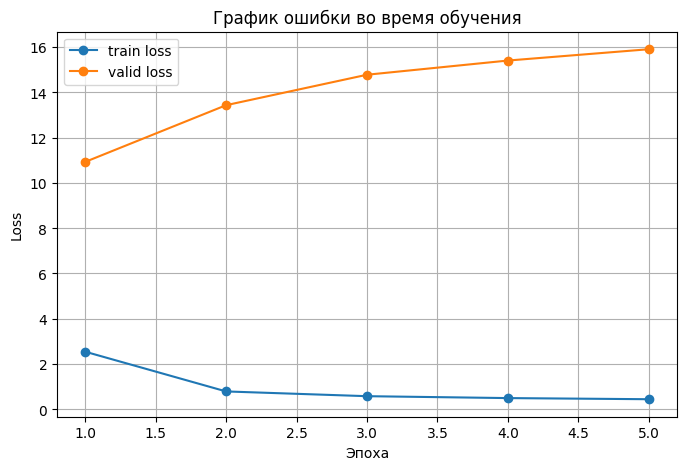

История обучения:

Эпоха 1: train_loss = 2.5422, valid_loss = 10.9283
Эпоха 2: train_loss = 0.7874, valid_loss = 13.4338
Эпоха 3: train_loss = 0.5778, valid_loss = 14.7792
Эпоха 4: train_loss = 0.4938, valid_loss = 15.4060
Эпоха 5: train_loss = 0.4436, valid_loss = 15.9061


In [48]:
import matplotlib.pyplot as plt

# Строим график изменения loss по эпохам
epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="train loss")
plt.plot(epochs, valid_losses, marker="o", label="valid loss")

plt.title("График ошибки во время обучения")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Заодно выведем значения в текстовом виде
print("История обучения:\n")
for i in range(len(train_losses)):
    print(
        f"Эпоха {i + 1}: "
        f"train_loss = {train_losses[i]:.4f}, "
        f"valid_loss = {valid_losses[i]:.4f}"
    )

In [49]:
# Загружаем лучшую сохранённую модель.
# Важно: map_location=device, чтобы веса сразу легли
# на CPU или GPU в зависимости от текущего устройства.

best_model = GPT(
    vocab_size=vocab_size,
    max_seq_len=max_seq_len,
    emb_size=emb_size,
    num_heads=num_heads,
    head_size=head_size,
    num_layers=num_layers,
    dropout=dropout
)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model = best_model.to(device)
best_model.eval()

print("Лучшая модель загружена.")
print("Устройство модели:", device)

# Если работаем на GPU, можно посмотреть,
# сколько памяти сейчас занято.
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Память выделено (MB):", round(torch.cuda.memory_allocated() / 1024**2, 2))
    print("Память зарезервировано (MB):", round(torch.cuda.memory_reserved() / 1024**2, 2))

Лучшая модель загружена.
Устройство модели: cuda
GPU: NVIDIA GeForce RTX 3070
Память выделено (MB): 763.68
Память зарезервировано (MB): 1922.0


In [50]:
@torch.no_grad()
def generate_text(model, bpe, start_text, max_new_tokens=100, temperature=1.0, do_sample=True):
    """
    Генерирует текст по начальному фрагменту.
    
    model      - обученная GPT-модель
    bpe        - токенизатор
    start_text - начальная строка
    """
    # Кодируем начальный текст
    start_ids = bpe.encode(start_text)

    # Если начальный текст слишком длинный,
    # оставляем только последние max_seq_len токенов
    start_ids = start_ids[-model.max_seq_len:]

    # Делаем тензор формы (1, T)
    x = torch.tensor([start_ids], dtype=torch.long).to(device)

    # Генерация идёт на том же устройстве,
    # где находится модель. Если device == "cuda",
    # значит генерация тоже будет с использованием GPU.
    generated_ids = model.generate(
        start_tokens=x,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature
    )

    # Переводим результат обратно в список id
    generated_ids = generated_ids[0].tolist()

    # Декодируем в текст
    generated_text = bpe.decode(generated_ids)

    return generated_text


# Можно взять любое начало текста.
# Лучше брать что-то короткое и понятное.
start_text = all_text[:80]

generated_text = generate_text(
    model=best_model,
    bpe=bpe,
    start_text=start_text,
    max_new_tokens=200,
    temperature=0.9,
    do_sample=True
)

print("Начальный текст:\n")
print(start_text)

print("\n" + "=" * 80)
print("Сгенерированный текст после обучения:\n")
print(generated_text)

Начальный текст:

Джек Сумасшедший король
Андрей Олегович Белянин


Джек Сумасшедший король #1
Сам

Сгенерированный текст после обучения:

Джек Сумасшедший король
Андрей Олегович Белянин


Джек Сумасшедший король #1
Самраскраскладывая молча и одним в шоро возеративно сторженной магически выглянулись в обнял Сумасшедшего короля, и чувствовавших струнки зумно не понимались по плечами грозным огнем налость.

– Славлюбленную девятых уть даль стоял – не по счур с бакенбардами деловито отвечал от воположный грохотнившего фигуры. Лагун! За грохарчевтаяся между шую отцом Доминик, но накрыл досадник Чарльз Ли тронет, как растряжку, исказир, народок Три вопрос, я размахивая руками до рванулся нежных взглядов и неожидан.

С вопрос фырей, у
